Explain those values:
1. Traditional values emphasize the importance of religion, parent-child ties, deference to authority and traditional family values. People who embrace these values also reject divorce, abortion, euthanasia and suicide. These societies have high levels of national pride and a nationalistic outlook.
2. Secular-rational values have the opposite preferences to the traditional values. These societies place less emphasis on religion, traditional family values and authority. Divorce, abortion, euthanasia and suicide are seen as relatively acceptable. (Suicide is not necessarily more common.)
3. Survival values place emphasis on economic and physical security. It is linked with a relatively ethnocentric outlook and low levels of trust and tolerance.
4. Self-expression values give high priority to environmental protection, growing tolerance of foreigners, gays and lesbians and gender equality, and rising demands for participation in decision-making in economic and political life

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
import seaborn as sns

import matplotlib.pyplot as plt

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

target_countries = ["Denmark", "Vietnam", "India", "Mexico"]
iv_qns = ["A008", "A165", "E018", "E025", "F063", "F118", "F120", "G006", "Y002", "Y003"]

X_axis_id = ["F063",'Y003','F120','G006', 'E018'] # Tranditional vs Secular-rational
Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 
from ultis import ivs_data, country_code

target_ivs_df = pd.DataFrame()

for country in target_countries:
	s003_code = country_code[country_code['country.territory'] == country]['s003'].values[0]
	survay_df = ivs_data[ivs_data['s003'] == s003_code][iv_qns]
	survay_df = survay_df.mean().to_frame().T
	survay_df['country'] = f"{country}_ivs"
	target_ivs_df = pd.concat([target_ivs_df, survay_df], ignore_index=True)

target_ivs_df


,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,country
0,1.697246,1.220599,1.603593,1.527186,3.759521,8.357605,8.270180,1.594491,2.067784,0.922635,Denmark_ivs
1,1.682927,1.603869,1.145080,2.703953,5.459209,3.753154,3.294786,1.303616,1.838940,0.551304,Vietnam_ivs
2,1.812292,1.810739,1.718882,2.313290,7.952296,2.189261,2.271356,1.308187,1.660750,0.197027,India_ivs
3,1.452692,1.872553,1.291803,2.291191,9.118271,4.327080,3.069331,1.266313,1.992455,-0.254282,Mexico_ivs


In [2]:
from ultis import load_direct_profile_data
import json

qwen_rc = load_direct_profile_data('../outputs/qwen/default_profile_responses_Qwen_Qwen3-4B-Instruct-2507.json', model_name="Qwen3-4B-Instruct")
# qwen_vcx = load_profile_data('../outputs/qwen/vector_steering_0.5X_Qwen_Qwen3-4B-Instruct-2507.json')
# qwen_vcy = load_profile_data('../outputs/qwen/vector_steering_0.5Y_Qwen_Qwen3-4B-Instruct-2507.json')
llama_rc = load_direct_profile_data('../outputs/llama3.2-3b_profile.json', model_name="Llama 3.2-3B")
gemma_rc = load_direct_profile_data('../outputs/gemma-4b-it_profile.json', model_name="Gemma 4B-IT")
direct_point_df = pd.DataFrame()
direct_point_df = pd.concat([qwen_rc, llama_rc, gemma_rc], ignore_index=True)
direct_point_df['color'] = ['red', 'blue', 'green']
direct_point_df

,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,RC1,RC2,country,color
0,3.00,2.00,1.52,2.00,4.50,10.00,6.74,3.00,1.94,-1.10,1.849540,1.183282,Qwen3-4B-Instruct,red
1,2.00,1.48,1.78,1.44,7.60,7.96,6.14,2.46,2.40,0.78,2.030087,0.456609,Llama 3.2-3B,blue
2,2.08,2.00,2.80,2.20,6.94,9.20,6.66,2.74,2.00,0.54,1.851091,1.123414,Gemma 4B-IT,green


In [3]:
# load qwen data from json
with open('../outputs/qwen/prompt_basic_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
	data = json.load(f)

direct_qwen_vector_df = pd.DataFrame()
for country in data:
	print(f"Country: {country}, Samples: {len(data[country])}")
	tmp = load_direct_profile_data(data[country], model_name=f"to {country}")
	tmp['color'] = 'purple'
	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)
 
with open('../outputs/qwen/prompt_advance_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
	data = json.load(f)

for country in data:
	print(f"Country: {country}, Samples: {len(data[country]["A008"])}")
	tmp = load_direct_profile_data(data[country], model_name=f"to {country}")
	tmp['color'] = 'orange'
	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)
 
# with open('../outputs/qwen/vector_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
# 	data = json.load(f)
# for country in data:
# 	print(f"Country: {country}, Samples: {len(data[country]["A008"])}")
# 	tmp = load_direct_profile_data(data[country], model_name=f"{country}_vector-steering")
# 	tmp['color'] = 'green'
# 	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)
direct_qwen_vector_df['begin_point'] = "Qwen3-4B-Instruct"
direct_qwen_vector_df

Country: India, Samples: 10
Country: Vietnam, Samples: 10
Country: Mexico, Samples: 10
Country: Denmark, Samples: 10
Country: India, Samples: 25
Country: Vietnam, Samples: 25
Country: Mexico, Samples: 25
Country: Denmark, Samples: 25


,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,RC1,RC2,country,color,begin_point
0,3.0,2.0,2.00,2.0,7.10,7.28,6.46,3.1,2.0,-1.00,0.957795,1.217255,to India,purple,Qwen3-4B-Instruct
1,3.0,2.0,1.96,2.0,6.20,6.60,5.52,3.7,1.0,-1.02,0.395032,1.841530,to Vietnam,purple,Qwen3-4B-Instruct
2,3.0,2.0,1.90,2.0,6.74,9.24,6.12,3.7,2.0,-1.56,1.310605,1.324980,to Mexico,purple,Qwen3-4B-Instruct
3,3.0,2.0,2.00,2.0,3.10,10.00,7.00,3.0,2.0,-1.48,1.944323,1.482147,to Denmark,purple,Qwen3-4B-Instruct
4,3.0,2.0,3.00,2.0,7.00,7.40,6.64,3.0,1.0,1.00,1.000856,2.123150,to India,orange,Qwen3-4B-Instruct
5,3.0,2.0,1.00,2.0,5.00,9.12,6.60,4.0,1.0,0.52,1.395838,2.144893,to Vietnam,orange,Qwen3-4B-Instruct
6,3.0,2.0,1.00,2.0,10.00,3.00,1.00,4.0,1.0,1.00,-1.215240,1.698516,to Mexico,orange,Qwen3-4B-Instruct
7,3.0,1.0,3.00,2.0,3.00,10.00,8.00,4.0,3.0,-0.44,2.673954,2.679850,to Denmark,orange,Qwen3-4B-Instruct


In [4]:
from ultis import load_probing_profile_data, answer_to_pivot
probing_qwen_point = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Qwen3-4B-Instruct")
# probing_qwen_point2 = load_probing_profile_data('../outputs/qwen_probing_results/qwen3-4b-probing.json', model_name="Qwen3-4B-Instruct2")
probing_llama_point = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/llama_prompt_steer_outputs/evaluation_results_default.json', model_name="Llama3.2-3B-Instruct")
probing_gemma_point = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/gemma_prompt_steer_outputs/evaluation_results_default.json', model_name="Gemma3-4B")

probing_points_df = pd.DataFrame()
probing_points_df = pd.concat([probing_qwen_point, probing_llama_point, probing_gemma_point], ignore_index=True)
probing_points_df['color'] = ['red' , 'blue', 'green']
probing_points_df

# X_axis_id = ["F063",'Y003','F120','G006', 'E018'] # Tranditional vs Secular-rational
# Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,color
0,All,4.992625,8.439901,1.432488,8.476071,3.620281,2.994382,3.870100,3.338209,1.475946,2.388735,9.692377,2.455231,2.058017,2.345887,Qwen3-4B-Instruct,red
1,All,3.562527,6.075041,0.485462,6.328134,2.607159,2.316841,3.101616,2.633818,1.479228,2.173716,7.138553,2.082766,1.420904,1.367224,Llama3.2-3B-Instruct,blue
2,All,5.099484,8.112990,1.489097,9.361956,3.622428,2.910947,3.830192,3.241235,1.520032,2.540864,9.695205,2.153625,2.091993,2.418891,Gemma3-4B,green


In [5]:
probing_qwen_vector_df = pd.DataFrame()
for country in target_countries:
	basic_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_prompt_steer_outputs/evaluation_results_basic{country}.json'
	advance_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_prompt_steer_outputs/evaluation_results_advanced_{country}.json'
	basic_df = load_probing_profile_data(basic_steering_file, model_name=f"to {country}")
	basic_df['color'] = 'purple'
	advance_df = load_probing_profile_data(advance_steering_file, model_name=f"to {country}")
	advance_df['color'] = 'orange'
	probing_qwen_vector_df = pd.concat([probing_qwen_vector_df, basic_df, advance_df], ignore_index=True)
 
probing_qwen_vector_df['begin_point'] = "Qwen3-4B-Instruct"

probing_gemma_vector_df = pd.DataFrame()
for country in target_countries:
	basic_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/gemma_prompt_steer_outputs/evaluation_results_basic{country}.json'
	advance_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/gemma_prompt_steer_outputs/evaluation_results_advanced_{country}.json'
	basic_df = load_probing_profile_data(basic_steering_file, model_name=f"to {country}")
	basic_df['color'] = 'purple'
	advance_df = load_probing_profile_data(advance_steering_file, model_name=f"to {country}")
	advance_df['color'] = 'orange'
	probing_gemma_vector_df = pd.concat([probing_gemma_vector_df, basic_df, advance_df], ignore_index=True)

probing_gemma_vector_df['begin_point'] = "Gemma3-4B"

probing_llama_vector_df = pd.DataFrame()
for country in target_countries:
	basic_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/llama_prompt_steer_outputs/evaluation_results_basic{country}.json'
	advance_steering_file = f'/home/ducanh/Desktop/KU_Study/Thesis/code/llama_prompt_steer_outputs/evaluation_results_advanced_{country}.json'
	basic_df = load_probing_profile_data(basic_steering_file, model_name=f"to {country}")
	basic_df['color'] = 'purple'
	advance_df = load_probing_profile_data(advance_steering_file, model_name=f"to {country}")
	advance_df['color'] = 'orange'
	probing_llama_vector_df = pd.concat([probing_llama_vector_df, basic_df, advance_df], ignore_index=True)
probing_llama_vector_df['begin_point'] = "Llama3.2-3B-Instruct"

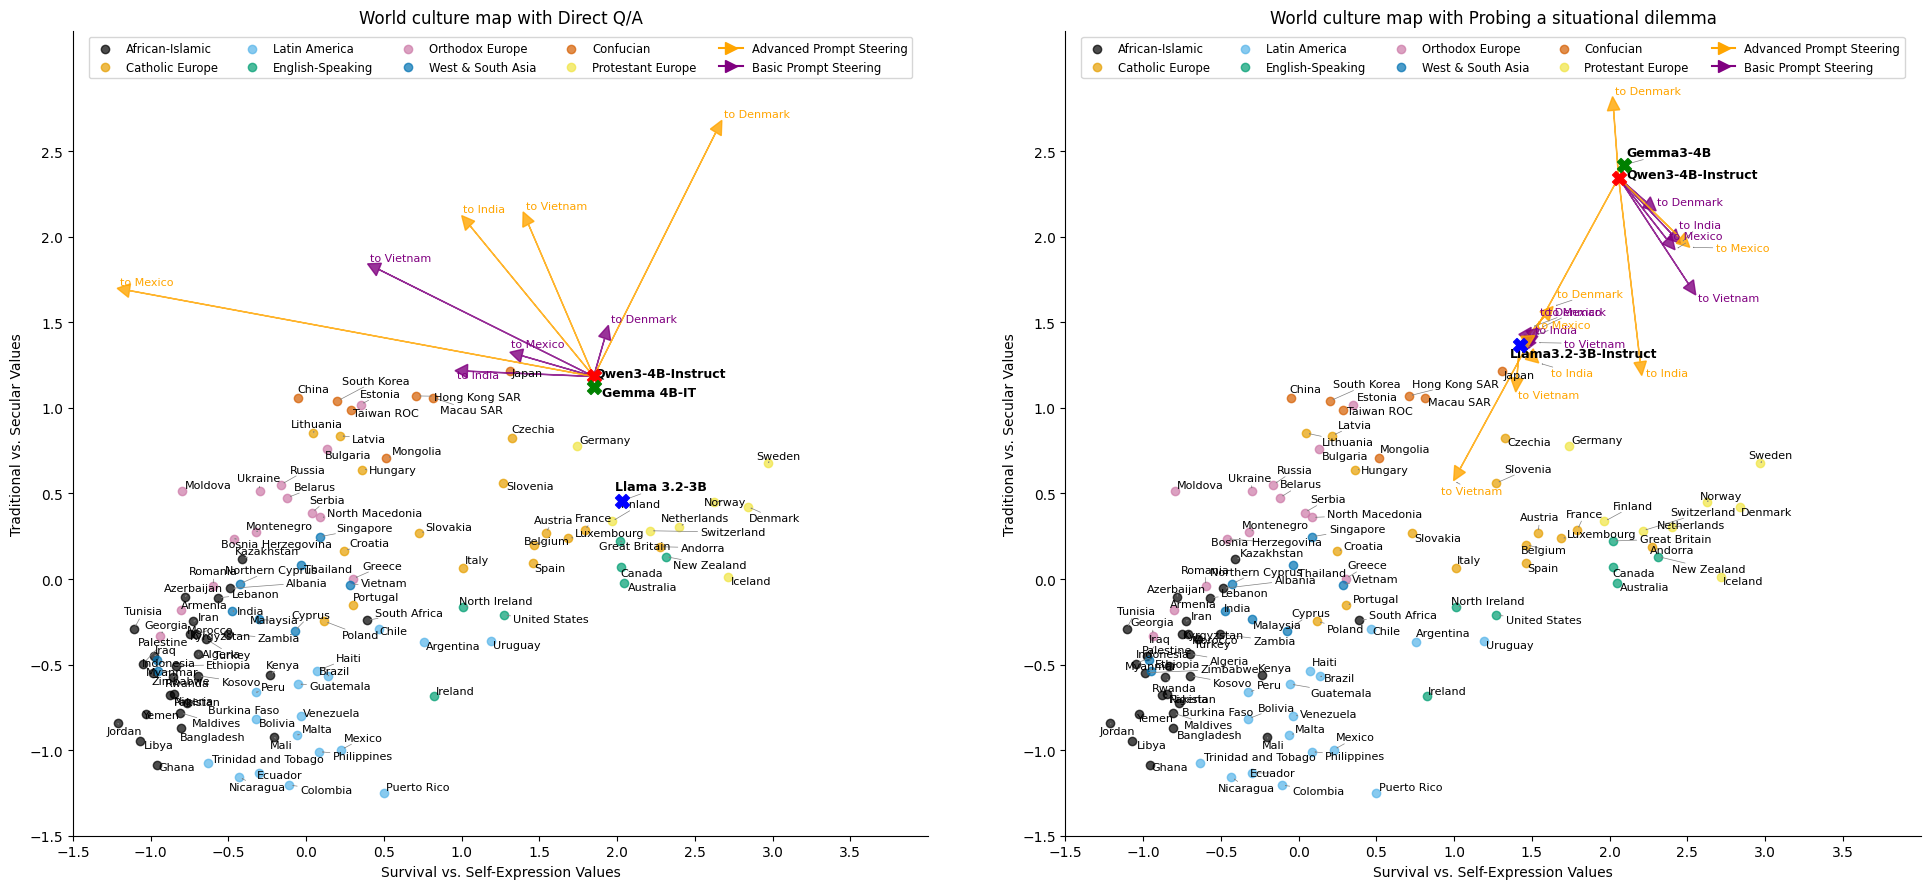

In [32]:
from ultis import plot_culture_map
# --- Execution: Plot side-by-side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
# plt.subplots_adjust(wspace=0)
plot_culture_map(ax=ax1, 
				 additional_points_df=direct_point_df, 
				 additional_vectors_df=direct_qwen_vector_df, 
				 title="World culture map with Direct Q/A",
				 legend=True)
plot_culture_map(ax=ax2, 
				 additional_points_df=probing_points_df, 
				 additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df]),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				#  additional_vectors_df=probing_qwen_vector_df, 
				 title="World culture map with Probing a situational dilemma",
				 legend=True)

plt.tight_layout()
plt.show()

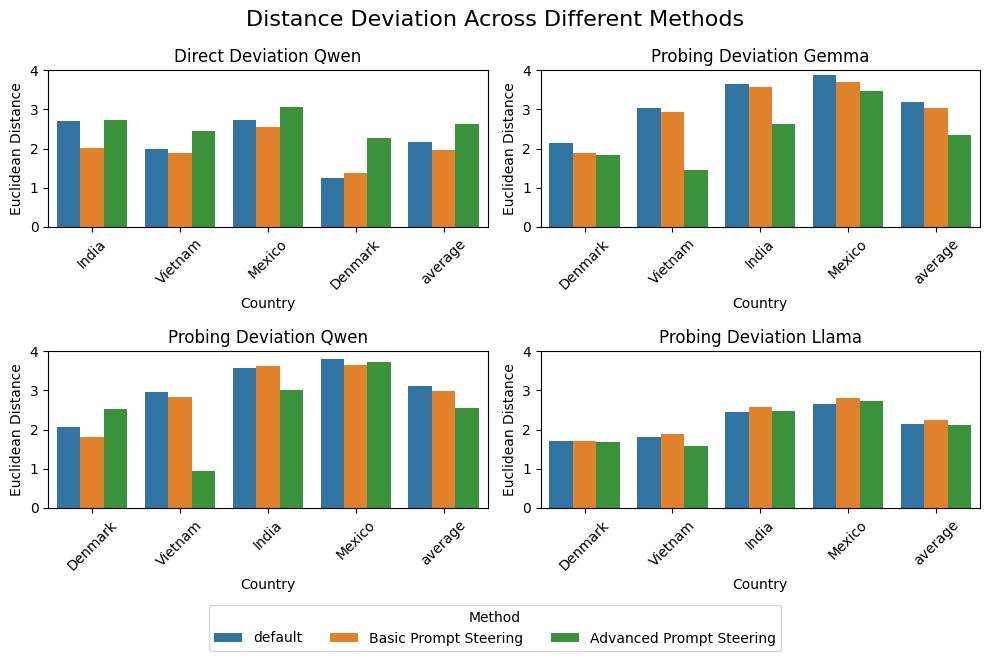

In [43]:
def plot_distance_deviation(additional_points_df, additional_vectors_df, ax=None, title=None, legend=True, is_norm=False):
	# 1. Handle Axes Logic
	is_standalone = ax is None
	if is_standalone:
		fig, ax = plt.subplots(figsize=(10, 6))
	
	# Assertions and Data Preparation
	assert additional_vectors_df['begin_point'].nunique() == 1, "Multiple begin_point types found"
	begin_point = additional_vectors_df['begin_point'].unique()[0]  
 
	additional_vectors_df['Target_country'] = additional_vectors_df['country'].apply(lambda x: x[3:])
	color_mapping = {
		'orange': 'Advanced Prompt Steering',
		'purple': 'Basic Prompt Steering',
		'blue': 'Vector Steering',
	}
	additional_vectors_df['Method'] = additional_vectors_df['color'].apply(lambda x: color_mapping.get(x, 'default'))
	
	if is_norm:
		scaler = StandardScaler()
		features_full = ivs_data[iv_qns]
		scaler.fit(features_full.dropna())
  
	all_methods = ['default'] + additional_vectors_df['Method'].unique().tolist()
	all_targets = additional_vectors_df['Target_country'].unique().tolist() + ['average']
	distance_results = {method: {country: None for country in all_targets} for method in all_methods}
		
	for country in target_countries:
		s003_code = country_code[country_code['country.territory'] == country]['s003'].values[0]
		if is_norm:
			survay_df = ivs_data[ivs_data['s003'] == s003_code][iv_qns].dropna()
			target_country_vectors = scaler.transform(survay_df).mean(0)
			default_vector = additional_points_df[additional_points_df['country'] == begin_point][iv_qns]
			default_vector_scaled = scaler.transform(default_vector)
		else:
			target_country_vectors = ivs_data[ivs_data['s003'] == s003_code][['RC1', 'RC2']].dropna().mean(0)
			default_vector_scaled = additional_points_df[additional_points_df['country'] == begin_point][['RC1', 'RC2']]

		distance_results['default'][country] = np.linalg.norm(default_vector_scaled - target_country_vectors)
  
		for method in all_methods:
			vector_row = additional_vectors_df[(additional_vectors_df['Target_country'] == country) & (additional_vectors_df['Method'] == method)]
			if not vector_row.empty:
				if is_norm:
					vector_df = vector_row[iv_qns]
					vector_alignment = scaler.transform(vector_df).mean(0)
				else:
					vector_df = vector_row[['RC1', 'RC2']]
					vector_alignment = vector_df.mean(0)
				distance_results[method][country] = np.linalg.norm(vector_alignment - target_country_vectors)
	
	for method in all_methods:
		distances = [distance_results[method][c] for c in target_countries if distance_results[method][c] is not None]
		if distances:
			distance_results[method]['average'] = np.mean(distances)
	# 2. Plotting using the provided 'ax'
	distance_df = pd.DataFrame(distance_results).reset_index().rename(columns={'index': 'country'})
	distance_df_melted = distance_df.melt(id_vars='country', var_name='model_type', value_name='distance')

	sns.barplot(data=distance_df_melted, x='country', y='distance', hue='model_type', ax=ax, legend=legend)
	
	# 3. Formatting
	ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
	ax.set_title(title if title else 'Distance between LLM and Survey profiles')
	ax.set_ylabel('Euclidean Distance')
	ax.set_xlabel('Country')
	ax.set_ylim(0, 4)
	
	# Place legend outside for clarity
	if legend:
		ax.legend(title='Method', loc='center left', bbox_to_anchor=(1, 0.5))

	if is_standalone:
		plt.tight_layout()
		plt.show()

# --- Example of side-by-side usage ---
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

plot_distance_deviation(additional_points_df=direct_point_df, 
						additional_vectors_df=direct_qwen_vector_df, 
						ax=axs[0, 0], 
						title="Direct Deviation Qwen",
						legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_qwen_vector_df, 
						ax=axs[1, 0], 
						title="Probing Deviation Qwen",legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_llama_vector_df, 
						ax=axs[1, 1], 
						title="Probing Deviation Llama",legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_gemma_vector_df,
						ax=axs[0, 1], 
						title="Probing Deviation Gemma",legend=True)

# 3. Now extract the handles from that last plot
handles, labels = axs[0, 1].get_legend_handles_labels()

# 4. Remove the legend from that specific subplot so it's clean
axs[0, 1].get_legend().remove()

# 5. Create the global figure legend at the bottom
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.1), 
           ncol=4, 
           title='Method')
fig.suptitle('Distance Deviation Across Different Methods', fontsize=16)
plt.tight_layout()
# Adjust bottom manually if the legend still overlaps
plt.subplots_adjust(bottom=0.15) 
plt.show()

In [24]:
# load vector steering results
probing_qwen_steer_vector_df = pd.DataFrame()



tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_X_-0.2.json', model_name="X=-0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_Y_0.2.json', model_name="Y=0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_Y_-0.2.json', model_name="Y=-0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_X_0.2.json', model_name="X=0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_-0.2_Y_-0.2.json', model_name="X=-0.2_Y=-0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_0.2_Y_-0.2.json', model_name="X=0.2_Y=-0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_-0.2_Y_0.2.json', model_name="X=-0.2_Y=0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_0.2_Y_0.2.json', model_name="X=0.2_Y=0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

probing_qwen_steer_vector_df['begin_point'] = "Qwen3-4B-Instruct"
probing_qwen_steer_vector_df['color'] = 'blue'
probing_qwen_steer_vector_df

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,begin_point,color
0,All,5.211374,8.128601,1.850874,9.198252,3.879732,2.999410,4.013614,3.527540,1.551351,2.625329,9.703245,2.660607,2.089439,2.797557,X=-0.2,Qwen3-4B-Instruct,blue
1,All,4.111465,7.995576,0.087635,7.016020,2.820037,2.638056,3.207647,2.583983,1.196955,1.822692,8.806973,1.627633,1.884324,1.091234,Y=0.2,Qwen3-4B-Instruct,blue
2,All,5.170006,7.963185,1.852706,9.187920,3.846873,2.999345,4.040547,3.532578,1.598252,2.688237,9.698886,2.684782,2.068125,2.809742,Y=-0.2,Qwen3-4B-Instruct,blue
3,All,3.932048,6.780083,0.313295,7.154155,2.776659,2.636049,3.375889,2.676577,1.294549,1.951598,9.063242,1.893478,2.036009,1.333694,X=0.2,Qwen3-4B-Instruct,blue


In [9]:
# load vector steering results
probing_llama_steer_vector_df = pd.DataFrame()


tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_-0.4.json', model_name="X=-0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_0.4.json', model_name="Y=0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_-0.4.json', model_name="Y=-0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_0.4.json', model_name="X=0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_0.2.json', model_name="Y=0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_0.2.json', model_name="X=0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_-0.2_Y_-0.2.json', model_name="X=-0.2_Y=-0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../outputs/llama_steering_outputs/evaluation_results_X_0.2_Y_-0.2.json', model_name="X=0.2_Y=-0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_-0.2_Y_0.2.json', model_name="X=-0.2_Y=0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_0.2_Y_0.2.json', model_name="X=0.2_Y=0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

probing_llama_steer_vector_df['begin_point'] = "Llama3.2-3B-Instruct"
probing_llama_steer_vector_df['color'] = 'blue'
probing_llama_steer_vector_df

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,begin_point,color
0,All,3.739658,6.357423,0.771732,6.376461,2.815894,2.376779,3.199687,2.785237,1.549300,2.194016,7.266251,2.203632,1.407757,1.610716,X=-0.4,Llama3.2-3B-Instruct,blue
1,All,3.112191,5.623496,-0.093477,5.629225,2.377162,2.024550,2.699283,2.372074,1.453625,1.989584,5.790587,1.890544,1.057589,0.989423,Y=0.4,Llama3.2-3B-Instruct,blue
2,All,3.735194,6.140686,0.785338,6.529960,2.806084,2.413902,3.244147,2.782923,1.575115,2.262851,7.389898,2.209949,1.446887,1.657253,Y=-0.4,Llama3.2-3B-Instruct,blue
3,All,3.017045,5.365591,-0.152091,5.487874,2.398464,1.985387,2.712307,2.377362,1.481365,2.033580,5.770617,1.898612,1.016367,1.017714,X=0.4,Llama3.2-3B-Instruct,blue
4,All,3.258047,5.776544,0.061686,5.872881,2.433283,2.145841,2.848443,2.442486,1.448831,2.056221,6.356466,1.938212,1.212097,1.085032,Y=0.2,Llama3.2-3B-Instruct,blue
5,All,3.209925,5.590285,0.051662,5.840292,2.438914,2.128474,2.868363,2.449792,1.473849,2.081485,6.383311,1.953378,1.208761,1.111451,X=0.2,Llama3.2-3B-Instruct,blue


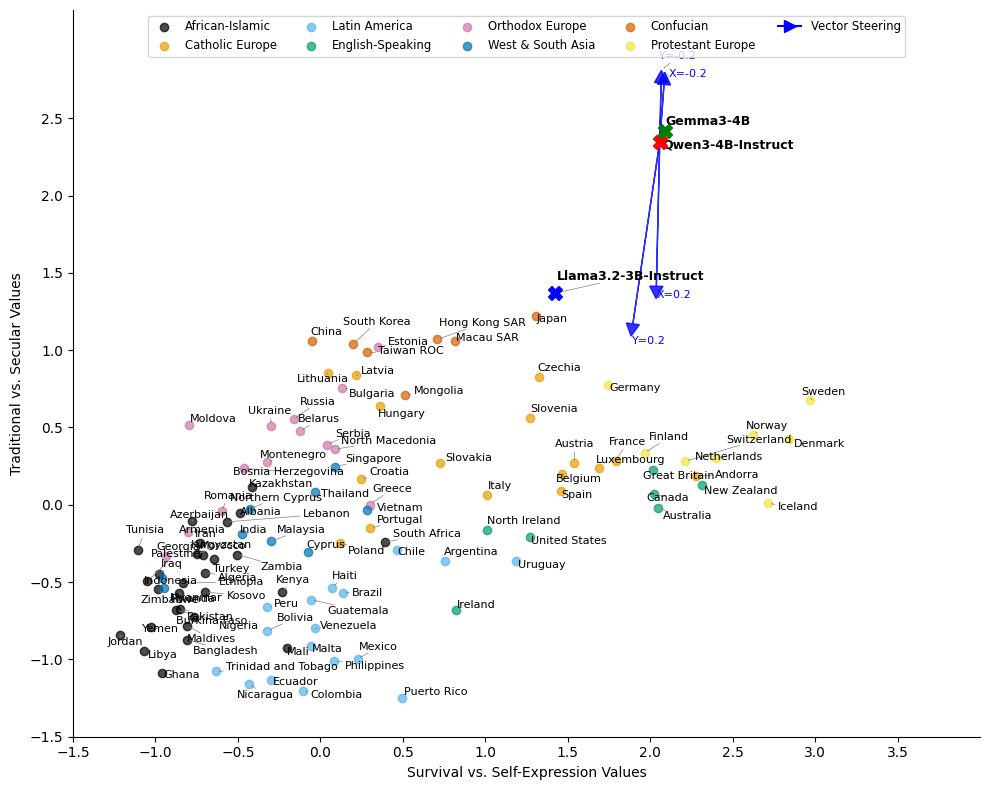

In [10]:
plot_culture_map(additional_points_df=probing_points_df, additional_vectors_df=probing_qwen_steer_vector_df)

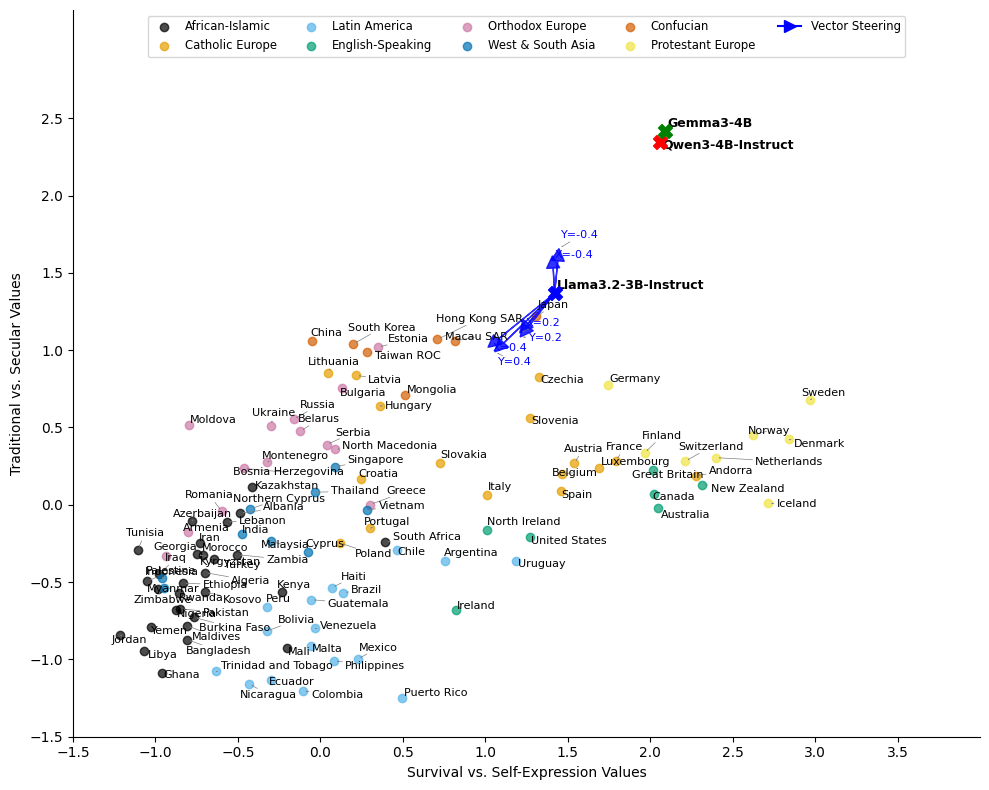

In [11]:
plot_culture_map(additional_points_df=probing_points_df, additional_vectors_df=probing_llama_steer_vector_df)

In [12]:

def compare_profile_on_axes(base_profile_path, target_profile_path, target_values='normalized_score'):
	# Load and pivot data
	if type(base_profile_path) is str:
		with open(base_profile_path, 'r') as f:
			df_base = answer_to_pivot(json.load(f), split_by_domain=True, target_values=target_values)
	else:
		df_base = answer_to_pivot(base_profile_path, split_by_domain=True, target_values=target_values)
	if type(target_profile_path) is str:
		with open(target_profile_path, 'r') as f:
			df_target = answer_to_pivot(json.load(f), split_by_domain=True, target_values=target_values)
	else:
		df_target = answer_to_pivot(target_profile_path, split_by_domain=True, target_values=target_values)
	# Define Axis IDs
	# RC2: Traditional vs Secular-rational
	X_axis_id = ["F063", "Y003", "F120", "G006", "E018"] 
	# RC1: Survival vs Self-expression
	Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 

	# Ensure we are comparing matching domains
	df_base = df_base.set_index('domain')
	df_target = df_target.set_index('domain')
	# Compute raw differences (Target - Base)
	# This shows the shift direction for every question
	df_diff = df_target - df_base

	# Compute average shift for each axis per domain
	results = pd.DataFrame(index=df_diff.index)
	
	# Calculate RC2 (Traditional/Secular) and RC1 (Survival/Expression)
	# We use .mean(axis=1) to average the columns in the specified lists
	results['Traditional_Secular_Shift'] = df_diff[X_axis_id].mean(axis=1)
	results['Survival_Expression_Shift'] = df_diff[Y_axis_id].mean(axis=1)

	# Optional: Calculate total Euclidean distance shift per domain
	results['Total_Magnitude'] = (results['Traditional_Secular_Shift']**2 + 
								  results['Survival_Expression_Shift']**2)**0.5

	return results, df_diff

base_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_prompt_steer_outputs_4/evaluation_results_default.json' 
target_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_All_X_0.2.json'

# Example Usage
comparison_results, differences = compare_profile_on_axes(base_profile, target_profile)
comparison_results

,Traditional_Secular_Shift,Survival_Expression_Shift,Total_Magnitude
domain,,,
Family,-0.284209,-0.227161,0.363836
Legal,-0.208605,-0.187274,0.280335
Workplace,-0.150073,-0.168339,0.225521
All,-0.214295,-0.194258,0.289238


In [13]:

base_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_prompt_steer_outputs_4/evaluation_results_default.json' 
target_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_All_Y_0.2.json'


# Example Usage
comparison_results, differences = compare_profile_on_axes(base_profile, target_profile)
comparison_results

,Traditional_Secular_Shift,Survival_Expression_Shift,Total_Magnitude
domain,,,
Family,-0.262369,-0.289342,0.390584
Legal,-0.209507,-0.258831,0.332997
Workplace,-0.123757,-0.247186,0.276435
All,-0.198544,-0.265120,0.331222


In [14]:
base_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/llama_prompt_steer_outputs/evaluation_results_default.json' 
target_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/llama_steering_outputs/results_All_X_0.2.json'

# Example Usage
comparison_results, differences = compare_profile_on_axes(base_profile, target_profile)
comparison_results

,Traditional_Secular_Shift,Survival_Expression_Shift,Total_Magnitude
domain,,,
Family,-0.098676,-0.052677,0.111856
Legal,-0.061763,-0.043450,0.075515
Workplace,-0.059630,-0.060741,0.085119
All,-0.073356,-0.052289,0.090085


In [15]:

base_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/llama_prompt_steer_outputs/evaluation_results_default.json' 
target_profile = '/home/ducanh/Desktop/KU_Study/Thesis/code/llama_steering_outputs/results_All_Y_0.2.json'

# Example Usage
comparison_results, differences = compare_profile_on_axes(base_profile, target_profile)
comparison_results

,Traditional_Secular_Shift,Survival_Expression_Shift,Total_Magnitude
domain,,,
Family,-0.086943,-0.061189,0.106316
Legal,-0.058091,-0.050368,0.076886
Workplace,-0.054858,-0.075703,0.093490
All,-0.066630,-0.062420,0.091301


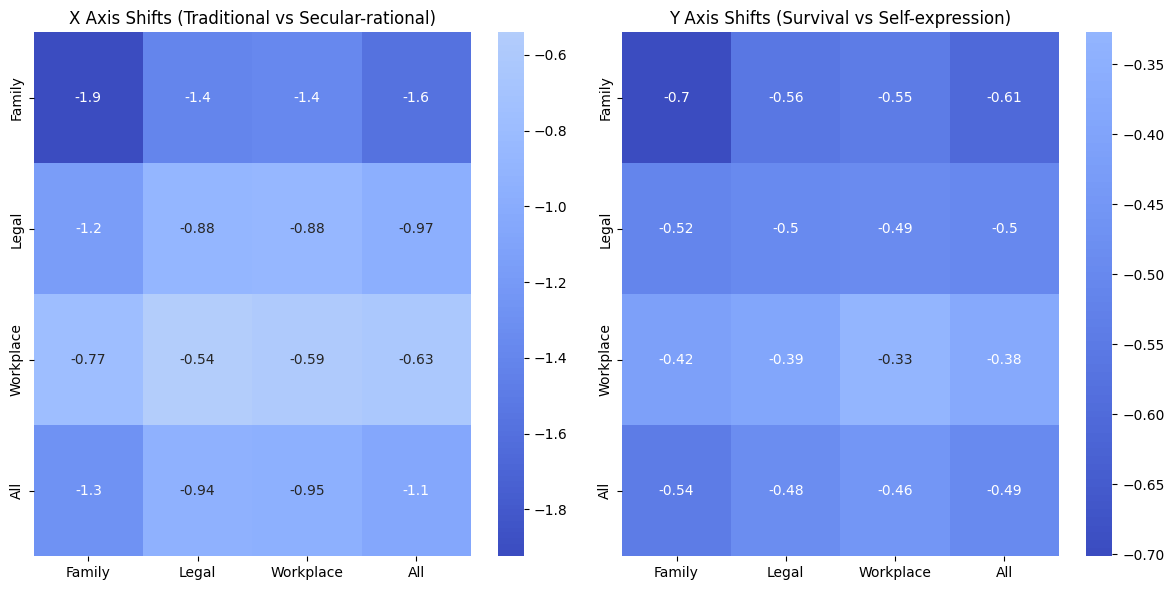

In [16]:
family_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Family_X_0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Legal_X_0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Workplace_X_0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_All_X_0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_df = pd.DataFrame()
Y_df = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_df = pd.concat([X_df, (df['X']-default_profile['X']).rename(name[i])], axis=1)
	Y_df = pd.concat([Y_df, (df['Y']-default_profile['Y']).rename(name[i])], axis=1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(X_df, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_df, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.tight_layout()
plt.show()

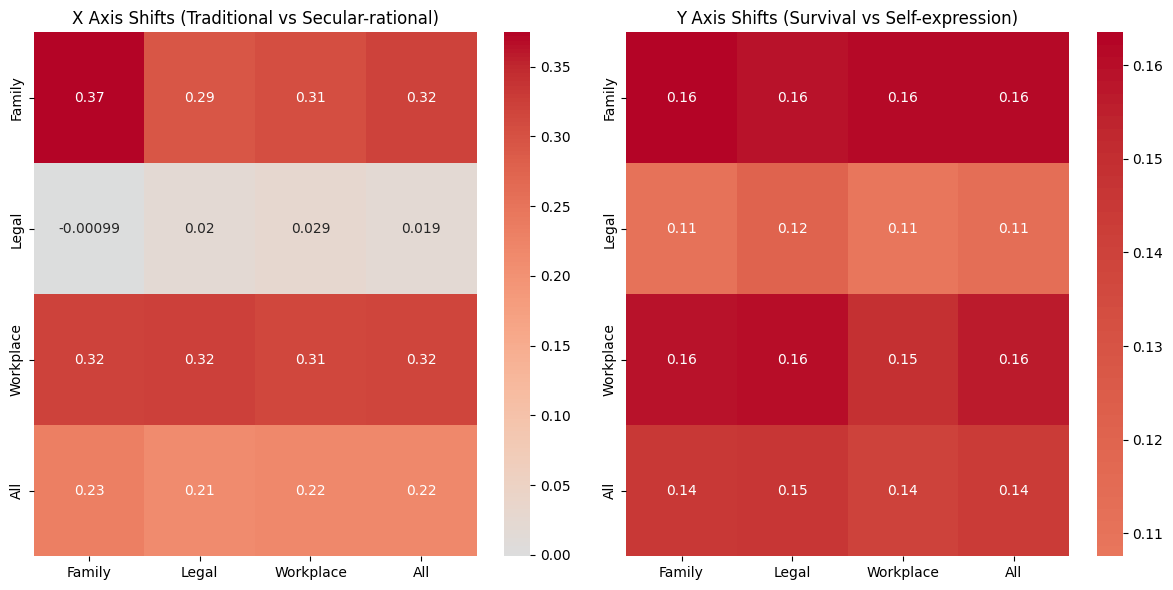

In [17]:
family_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Family_X_-0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Legal_X_-0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Workplace_X_-0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_All_X_-0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_df = pd.DataFrame()
Y_df = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_df = pd.concat([X_df, (df['X']-default_profile['X']).rename(name[i])], axis=1)
	Y_df = pd.concat([Y_df, (df['Y']-default_profile['Y']).rename(name[i])], axis=1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(X_df, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_df, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.tight_layout()
plt.show()

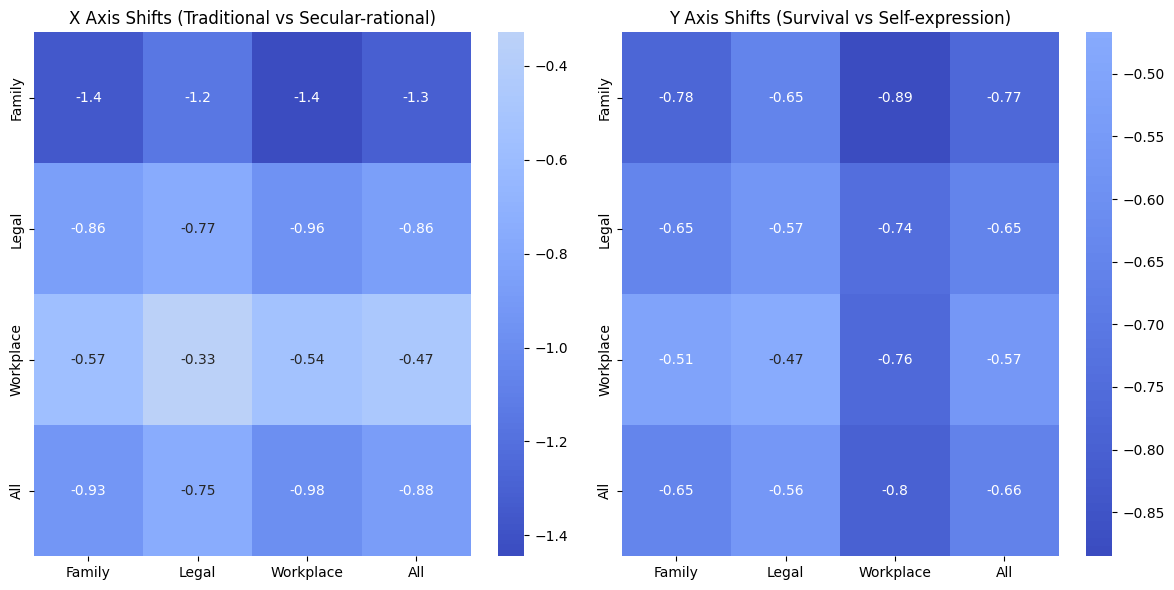

In [18]:
family_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Family_Y_0.2.json', model_name="X=0.2", split_by_domain=True)
legal_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Legal_Y_0.2.json', model_name="X=0.2", split_by_domain=True)
work_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_Workplace_Y_0.2.json', model_name="X=0.2", split_by_domain=True)
combine_domain = load_probing_profile_data('/home/ducanh/Desktop/KU_Study/Thesis/code/qwen_steering_outputs_4/results_All_Y_0.2.json', model_name="X=0.2", split_by_domain=True)

default_profile = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Default", split_by_domain=True)
default_profile.set_index('domain', inplace=True)

X_df = pd.DataFrame()
Y_df = pd.DataFrame()
name = ['Family', 'Legal', 'Workplace', 'All']
# select X columns only and stack 4 datafrmes and rename domain column to Method
for i, df in enumerate([family_domain, legal_domain, work_domain, combine_domain]):
	df.set_index('domain', inplace=True)
	#get domain by variable name
	X_df = pd.concat([X_df, (df['X']-default_profile['X']).rename(name[i])], axis=1)
	Y_df = pd.concat([Y_df, (df['Y']-default_profile['Y']).rename(name[i])], axis=1)
# plot 2 heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(X_df, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('X Axis Shifts (Traditional vs Secular-rational)')
sns.heatmap(Y_df, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Y Axis Shifts (Survival vs Self-expression)')
plt.tight_layout()
plt.show()